In [1]:
# What Is the Relationship Between ...
# ...the Government Budget Allocation...
# and the Growth in Childhood Obesity Rates...
# under different local authorities?

In [2]:
import statsmodels.api as sms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
rawdata = pd.read_csv('coursework_1_data_2019.csv')
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   local_authority_area  152 non-null    object
 1   2008_cases_total      152 non-null    int64 
 2   2013_cases_total      152 non-null    int64 
 3   2018_cases_total      152 non-null    int64 
 4   2008_pop_total        152 non-null    int64 
 5   2013_pop_total        152 non-null    int64 
 6   2018_pop_total        152 non-null    int64 
 7   2008_cases_male       152 non-null    int64 
 8   2013_cases_male       152 non-null    int64 
 9   2018_cases_male       152 non-null    int64 
 10  2008_pop_male         152 non-null    int64 
 11  2013_pop_male         152 non-null    int64 
 12  2018_pop_male         152 non-null    int64 
 13  2008_cases_female     152 non-null    int64 
 14  2013_cases_female     152 non-null    int64 
 15  2018_cases_female     152 non-null    in

In [4]:
# Encoding categorial variables
data = rawdata.drop(['local_authority_area','region'],axis=1)
data = pd.get_dummies(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 30 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   2008_cases_total                              152 non-null    int64
 1   2013_cases_total                              152 non-null    int64
 2   2018_cases_total                              152 non-null    int64
 3   2008_pop_total                                152 non-null    int64
 4   2013_pop_total                                152 non-null    int64
 5   2018_pop_total                                152 non-null    int64
 6   2008_cases_male                               152 non-null    int64
 7   2013_cases_male                               152 non-null    int64
 8   2018_cases_male                               152 non-null    int64
 9   2008_pop_male                                 152 non-null    int64
 10  2013_pop_male 

In [5]:
# Drop useless columns and reference level
data_final = data.drop(['local_authority_type_london_borough','2013_cases_total','2013_pop_total',
                       '2008_cases_male','2013_cases_male','2018_cases_male','2008_pop_male','2013_pop_male',
                       '2018_pop_male','2008_cases_female','2013_cases_female','2018_cases_female','2008_pop_female','2013_pop_female',
                       '2018_pop_female'],axis=1)
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 15 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   2008_cases_total                              152 non-null    int64
 1   2018_cases_total                              152 non-null    int64
 2   2008_pop_total                                152 non-null    int64
 3   2018_pop_total                                152 non-null    int64
 4   total_budget                                  152 non-null    int64
 5   clean_air                                     152 non-null    int64
 6   clean_environ                                 152 non-null    int64
 7   health_training                               152 non-null    int64
 8   school_awareness                              152 non-null    int64
 9   media_awareness                               152 non-null    int64
 10  sub_counsellin

In [6]:
# Calculating the new columns
data_final.loc[:,'co_diff_ra'] = data_final['2018_cases_total']/data_final['2018_pop_total'] - data_final['2008_cases_total']/data_final['2008_pop_total']
data_final.loc[:,'clean_air'] = data_final['clean_air']/data_final['total_budget']
data_final.loc[:,'clean_environ'] = data_final['clean_environ']/data_final['total_budget']
data_final.loc[:,'health_training'] = data_final['health_training']/data_final['total_budget']
data_final.loc[:,'school_awareness'] = data_final['school_awareness']/data_final['total_budget']
data_final.loc[:,'media_awareness'] = data_final['media_awareness']/data_final['total_budget']
data_final.loc[:,'sub_counselling'] = data_final['sub_counselling']/data_final['total_budget']

data_final = data_final.drop(['2008_cases_total','2018_cases_total','2008_pop_total','2018_pop_total','total_budget'],axis = 1)
data_final

,clean_air,clean_environ,health_training,school_awareness,media_awareness,sub_counselling,local_authority_type_metropolitan_borough,local_authority_type_non_metropolitan_county,local_authority_type_other_london,local_authority_type_unitary_authority,co_diff_ra
0,0.151079,0.158273,0.129496,0.294964,0.129496,0.136691,0,0,0,0,0.000763
1,0.227273,0.077273,0.104545,0.336364,0.136364,0.118182,0,0,0,0,0.000588
2,0.256250,0.281250,0.031250,0.162500,0.181250,0.087500,1,0,0,0,0.000456
3,0.204969,0.260870,0.118012,0.310559,0.062112,0.043478,0,0,0,1,0.000056
4,0.284615,0.400000,0.130769,0.061538,0.023077,0.100000,0,0,0,1,0.000187
...,...,...,...,...,...,...,...,...,...,...,...
147,0.330144,0.224880,0.143541,0.196172,0.066986,0.038278,1,0,0,0,0.000487
148,0.183486,0.376147,0.119266,0.174312,0.091743,0.055046,0,0,0,1,0.000274
149,0.089552,0.134328,0.114428,0.273632,0.248756,0.139303,1,0,0,0,0.000530
150,0.272340,0.238298,0.121277,0.161702,0.142553,0.063830,0,1,0,0,0.000222


Text(0.5, 1.0, 'Correlation Matrix')

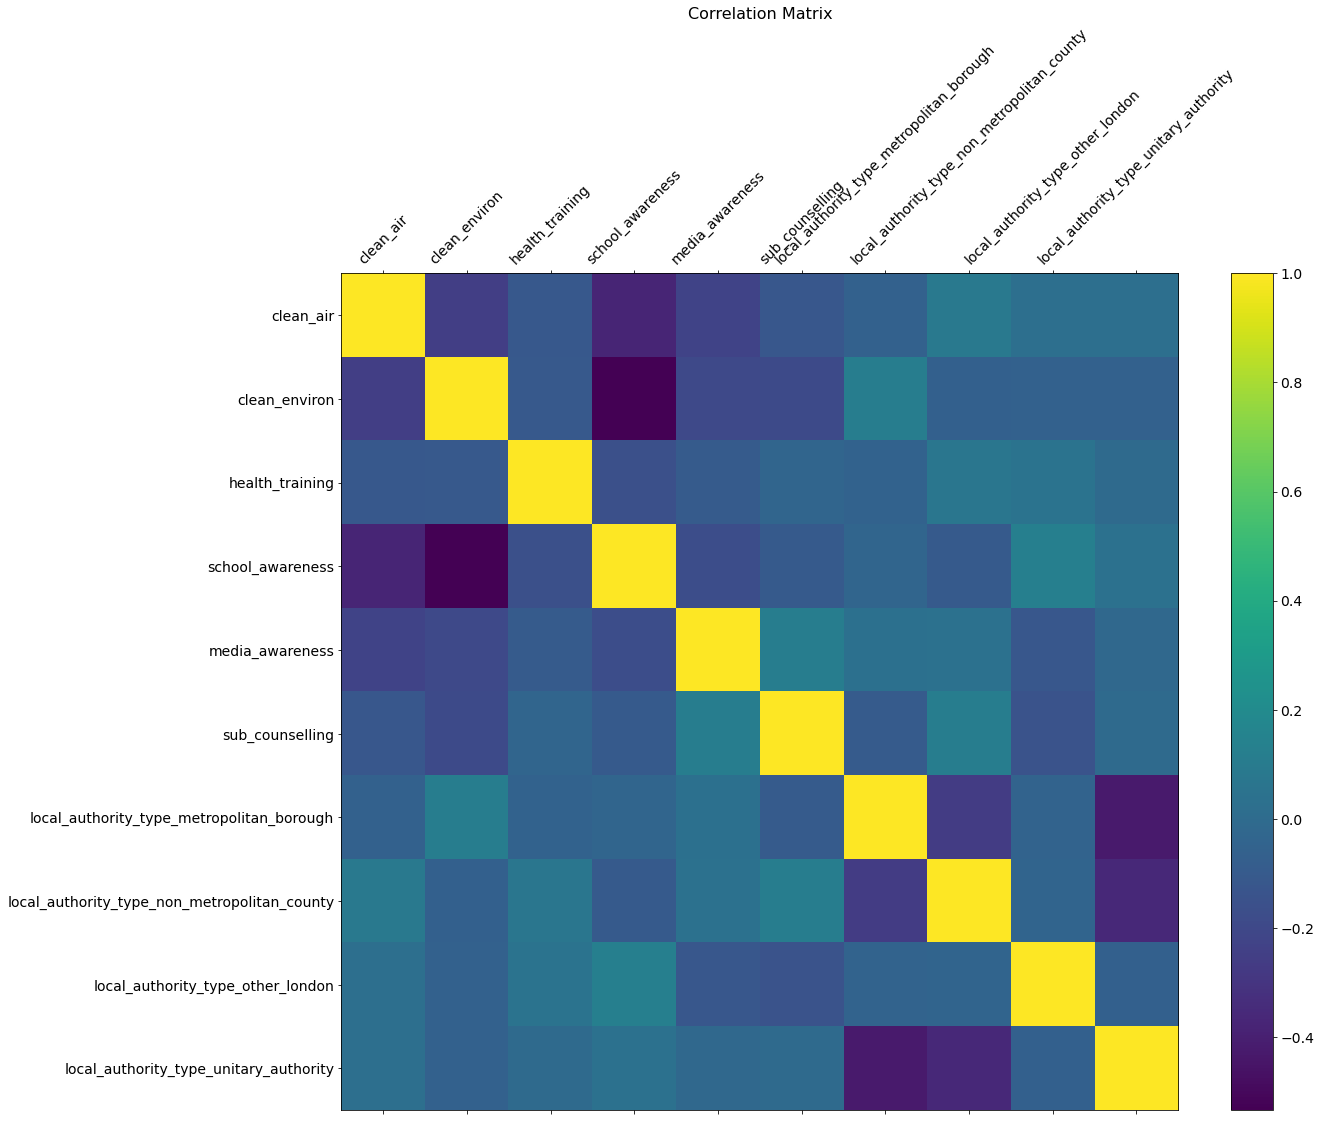

In [7]:
# Checking correlations
x_values = data_final.drop(['co_diff_ra'],axis = 1)
plt.rcParams["axes.grid"] = False
f = plt.figure(figsize=(19, 15))
plt.matshow(x_values.corr(), fignum=f.number)
plt.xticks(range(x_values.shape[1]), x_values.columns, fontsize=14, rotation=45)
plt.yticks(range(x_values.shape[1]), x_values.columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16)

In [8]:
# Drop the variable which causing perfect multicollinearity(local_authority_type_other_london)...
#...or p>0.05（school_awareness)
data_final = data_final.drop(['local_authority_type_other_london','school_awareness'],axis = 1)
#print(data_final)

In [9]:
# Manipulating Outliers
# ================ 异常值检验函数：iqr & z分数 两种方法 =========================
def outlier_test(data, column, z=2):
    print(f'Using the {column} column as a basis, the z-quantile method is used to detect outliers by taking {z} as the z-quantile...')
    print('=' * 70)
    # Calculating the numerical points of two Z-scores
    mean, std = np.mean(data[column]), np.std(data[column])
    upper, lower = (mean + z * std), (mean - z * std)
    print(f"Take {z} z-scores: anything greater than {upper} or less than {lower} is considered an outlier.")
    print('=' * 70)
 # Detection of outliers
    outlier = data[(data[column] <= lower) | (data[column] >= upper)]
    return outlier, upper, lower
    
outlier, upper, lower = outlier_test(data=data_final, column='clean_air')
data_final.drop(index=outlier.index, inplace=True)
outlier, upper, lower = outlier_test(data=data_final, column='clean_environ')
data_final.drop(index=outlier.index, inplace=True)
outlier, upper, lower = outlier_test(data=data_final, column='health_training')
data_final.drop(index=outlier.index, inplace=True)
#outlier, upper, lower = outlier_test(data=data_final, column='school_awareness')
#data_final.drop(index=outlier.index, inplace=True)
outlier, upper, lower = outlier_test(data=data_final, column='sub_counselling')
data_final.drop(index=outlier.index, inplace=True)

data_final.info()
#print(data_final)

Using the clean_air column as a basis, the z-quantile method is used to detect outliers by taking 2 as the z-quantile...
Take 2 z-scores: anything greater than 0.382083932371177 or less than 0.04997075436512524 is considered an outlier.
Using the clean_environ column as a basis, the z-quantile method is used to detect outliers by taking 2 as the z-quantile...
Take 2 z-scores: anything greater than 0.43681365657799576 or less than 0.06086496440786024 is considered an outlier.
Using the health_training column as a basis, the z-quantile method is used to detect outliers by taking 2 as the z-quantile...
Take 2 z-scores: anything greater than 0.1762707499543369 or less than 0.01348146599843783 is considered an outlier.
Using the sub_counselling column as a basis, the z-quantile method is used to detect outliers by taking 2 as the z-quantile...
Take 2 z-scores: anything greater than 0.14161670970338044 or less than 0.01416546056044718 is considered an outlier.
<class 'pandas.core.frame.DataF

In [10]:
# calculating VIF
# This function is adjusted from: https://stackoverflow.com/a/51329496/4667568
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.tools.tools import add_constant

def drop_column_using_vif_(df, thresh=5):
    '''
    Calculates VIF each feature in a pandas dataframe, and repeatedly drop the columns with the highest VIF
    A constant must be added to variance_inflation_factor or the results will be incorrect

    :param df: the pandas dataframe containing only the predictor features, not the response variable
    :param thresh: (default 5) the threshould VIF value. If the VIF of a variable is greater than thresh, it should be removed from the dataframe
    :return: dataframe with multicollinear features removed
    '''
    while True:
        # adding a constatnt item to the data
        ##df_with_const = add_constant(df)

        vif_df = pd.Series([variance_inflation_factor(df.values, i) 
               for i in range(df.shape[1])], name= "VIF",
              index=df.columns).to_frame()

        # drop the const
        vif_df = vif_df.drop('const')
        
        # Print vif values
        vif_data = pd.DataFrame()
        vif_data["feature"] = df.columns
        vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                           for i in range(len(df.columns))]
        print(vif_data.drop([0]))
        
        # if the largest VIF is above the thresh, remove a variable with the largest VIF
        # If there are multiple variabels with VIF>thresh, only one of them is removed. This is because we want to keep as many variables as possible
        if vif_df.VIF.max() > thresh:
            # If there are multiple variables with the maximum VIF, choose the first one
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print('Dropping: {}'.format(index_to_drop))
            df = df.drop(columns = index_to_drop)
        else:
            # No VIF is above threshold. Exit the loop
            break

    return df

In [11]:
Y_values = data_final['co_diff_ra']
X_values = add_constant(data_final)
X_values = X_values.drop(columns = ['co_diff_ra'])

df_predictors_selected_VIF = drop_column_using_vif_(X_values)

print("The columns remaining after VIF selection are:")
print()
print(df_predictors_selected_VIF.columns)
#print(X_values)

                                        feature       VIF
1                                     clean_air  1.701227
2                                 clean_environ  1.559555
3                               health_training  1.334929
4                               media_awareness  1.512872
5                               sub_counselling  1.179572
6     local_authority_type_metropolitan_borough  1.573697
7  local_authority_type_non_metropolitan_county  1.467012
8        local_authority_type_unitary_authority  1.631539
The columns remaining after VIF selection are:

Index(['const', 'clean_air', 'clean_environ', 'health_training',
       'media_awareness', 'sub_counselling',
       'local_authority_type_metropolitan_borough',
       'local_authority_type_non_metropolitan_county',
       'local_authority_type_unitary_authority'],
      dtype='object')


/opt/conda/envs/sds2021/lib/python3.9/site-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [14]:
X_values = df_predictors_selected_VIF.drop(columns = ['const'])

cases_regression = sms.OLS(Y_values, X_values).fit()
cases_regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             co_diff_ra   R-squared (uncentered):                   0.901
Model:                            OLS   Adj. R-squared (uncentered):              0.895
Method:                 Least Squares   F-statistic:                              139.5
Date:                Sun, 14 Nov 2021   Prob (F-statistic):                    1.27e-57
Time:                        18:19:18   Log-Likelihood:                          971.90
No. Observations:                 130   AIC:                                     -1928.
Df Residuals:                     122   BIC:                                     -1905.
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
clean_air                                        0.0004      0.000      3.175      0.002       0.000       0.001
clean_environ                                    0.0005      0.000      4.520      0.000       0.000       0.001
health_training                                  0.0008      0.000      2.865      0.005       0.000       0.001
media_awareness                                  0.0016      0.000      7.849      0.000       0.001       0.002
sub_counselling                                  0.0017      0.000      4.170      0.000       0.001       0.003
local_authority_type_metropolitan_borough       -0.0002   3.54e-05     -5.630      0.000      -0.000      -0.000
local_authority_type_non_metropolitan_county    -0.0005   4.01e-05    -11.972      0.000      -0.001      -0.000
local_authority_type_unitary_authority          -0.0004   3.37e-05    -12.806      0.000      -0.000      -0.000
==============================================================================
Omnibus:                        8.872   Durbin-Watson:                   1.907
Prob(Omnibus):                  0.012   Jarque-Bera (JB):               17.535
Skew:                           0.156   Prob(JB):                     0.000156
Kurtosis:                       4.772   Cond. No.                         22.3
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

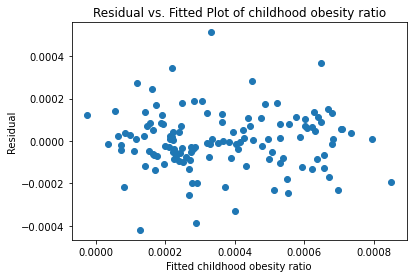

In [25]:
# plot 
plt.scatter(cases_regression.fittedvalues, cases_regression.resid)
# adding title and labels
plt.xlabel('Fitted childhood obesity ratio')
plt.ylabel('Residual')
plt.title('Residual vs. Fitted Plot of childhood obesity ratio')
plt.savefig("res_vs_fit.png")
plt.show()

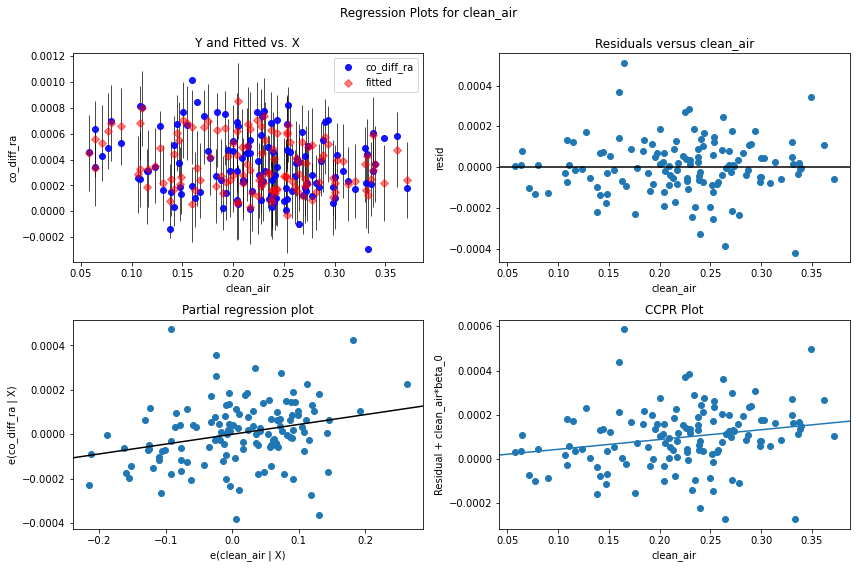

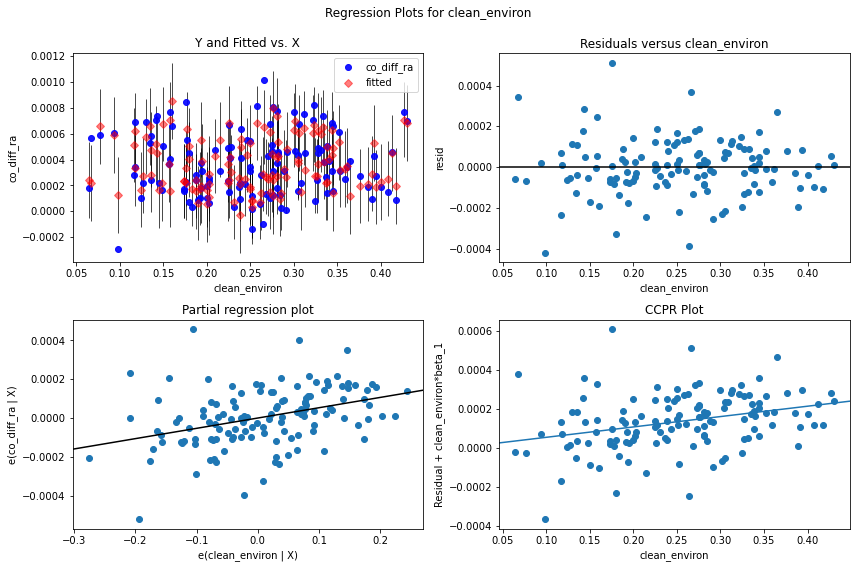

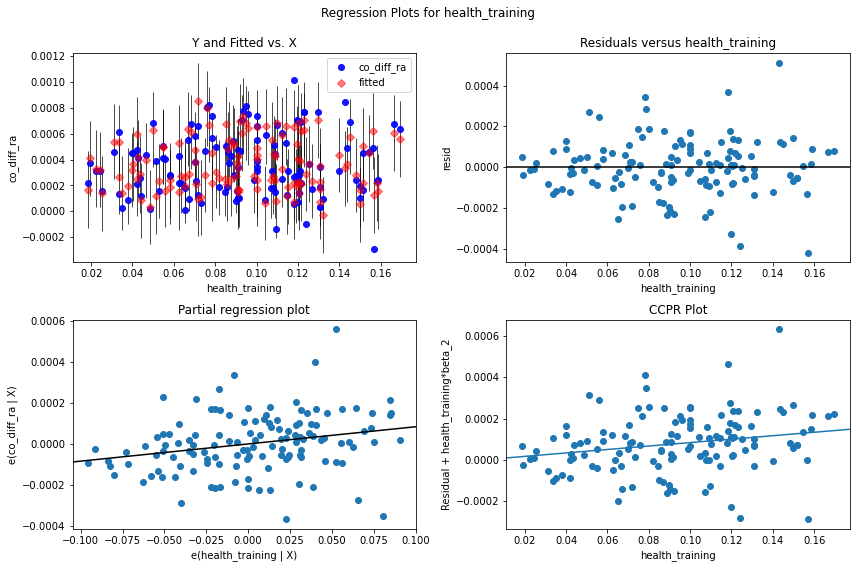

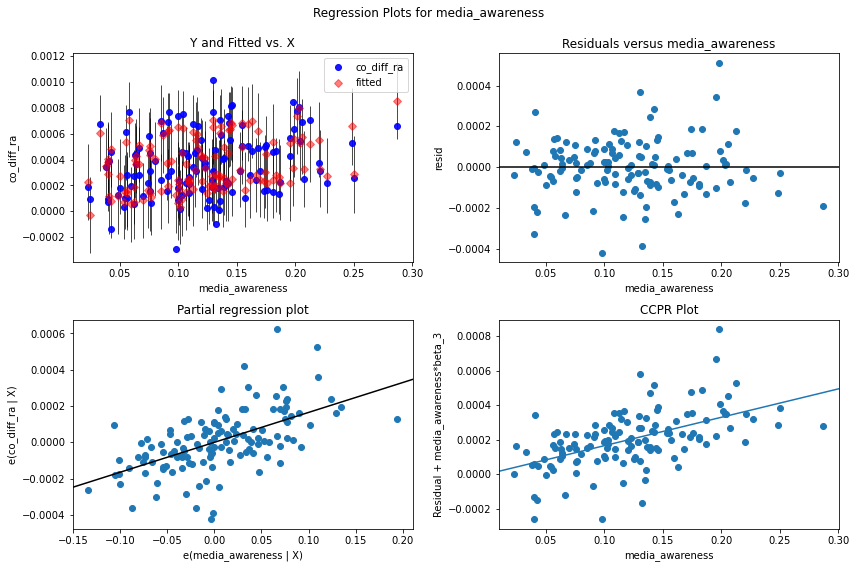

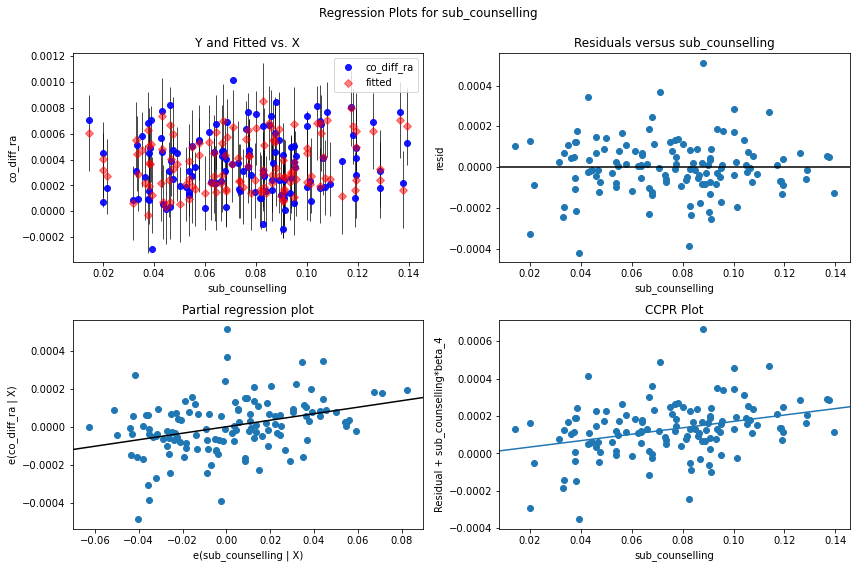

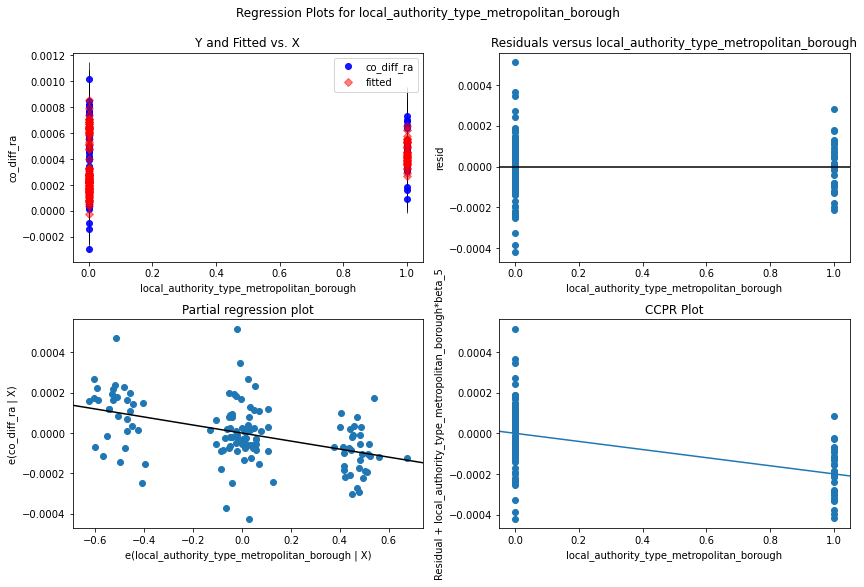

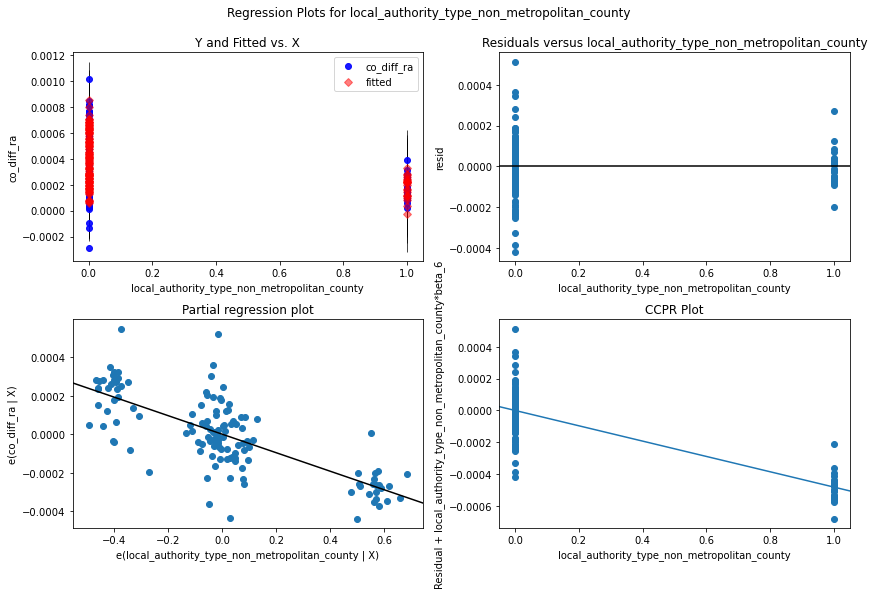

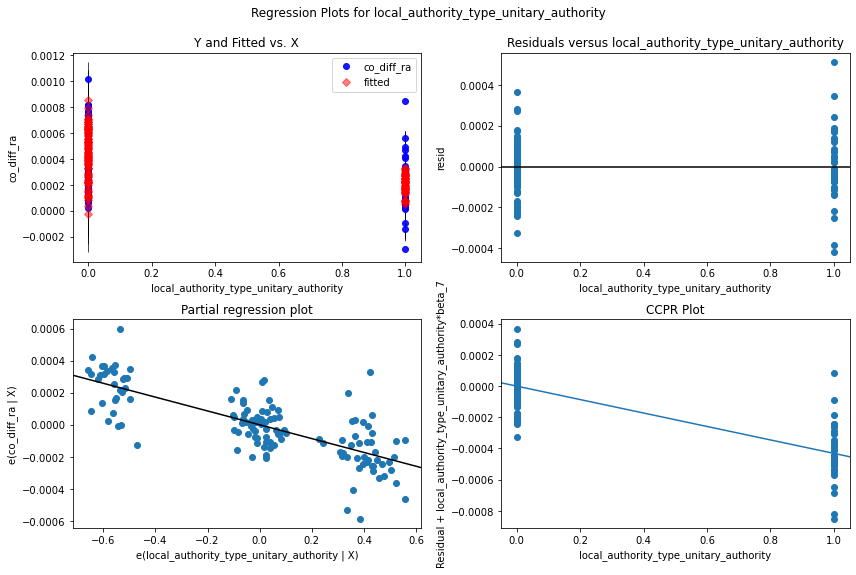

In [30]:
# Residual Analysis
column_names = X_values.columns.values.tolist()
for i in column_names:
    fig = plt.figure(figsize=(12,8))
    fig = sms.graphics.plot_regress_exog(cases_regression, i, fig=fig)
    

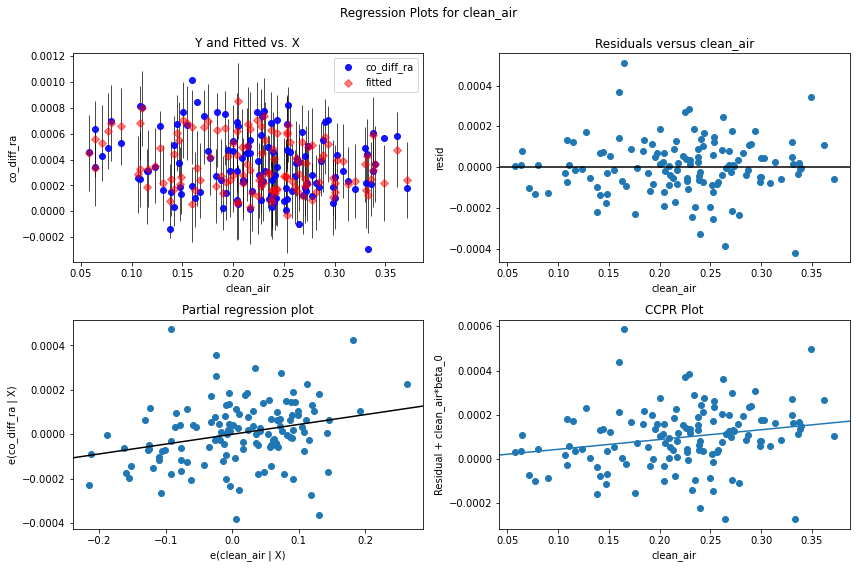

In [24]:
# Residual Analysis

fig = plt.figure(figsize=(12,8))
fig = sms.graphics.plot_regress_exog(cases_regression, 'clean_air', fig=fig)

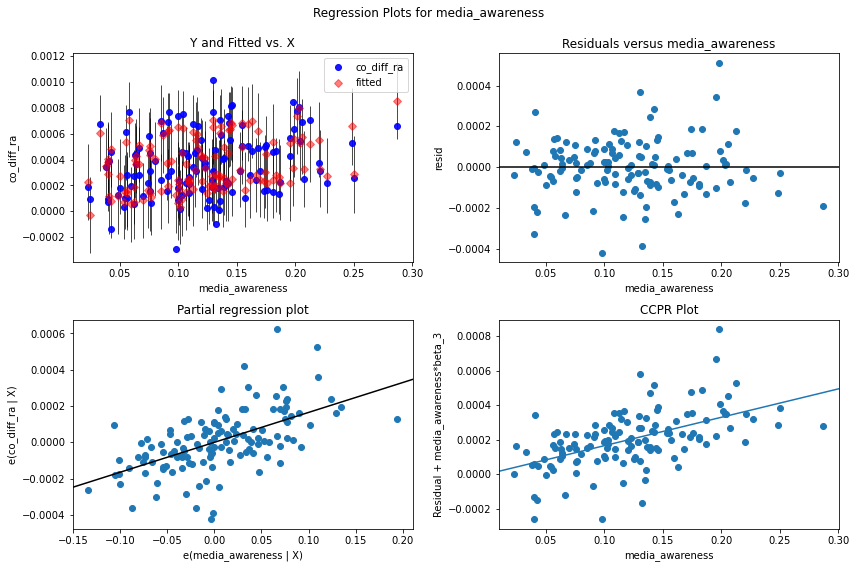

In [20]:
#media_awareness
fig = plt.figure(figsize=(12,8))
fig = sms.graphics.plot_regress_exog(cases_regression, 'media_awareness', fig=fig)

In [22]:
# Now we store all the relevant values:
#predictor_coeffs  = regression_model_b.params[1:]
#constant          = regression_model_b.params[0] # called the 'intercept' in simple regression
#Rsquared          = regression_model_b.rsquared
#MSE               = regression_model_b.mse_resid
#pvalues_T         = regression_model_b.pvalues[1:]
#pvalue_F          = regression_model_b.f_pvalue

# Print these summary stats:
#print("predictor coefficients =", predictor_coeffs)
#print("constant               =", constant)
#print("Rsquared               =", Rsquared)
#print("MSE                    =", MSE)
#print("T-test pvalues         =", pvalues_T)
#print("F-test pvalue          =", pvalue_F)